In [ ]:
- Set up model running function in external script
- Call this function to do parameter scans

In [22]:
import xarray as xr

import numpy as np

import time as tm

from multiprocessing import Pool

import warnings
warnings.simplefilter(action='ignore', category=(RuntimeWarning, FutureWarning))

In [23]:
from func_parallel import run_model_test

No event detected


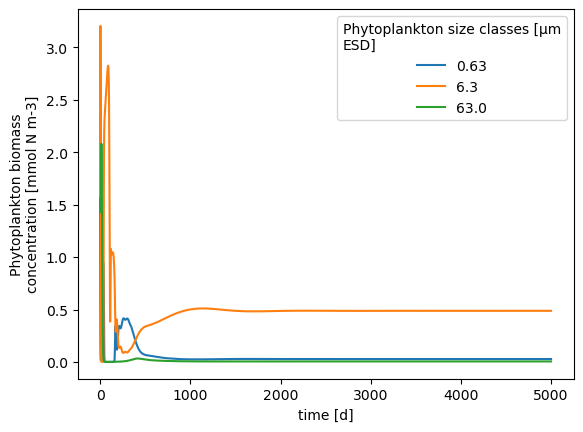

In [24]:
outttttt = run_model_test({'HigherOrderMortality__rate': 0.009})#.Phytoplankton__biomass.plot.line(x='time')
outttttt.Phytoplankton__biomass.plot.line(x='time')

In [17]:
def generate_iterable_2d_parscan(par1, par_range1, par2, par_range2):
    return [(par1,(val1, par2, [{par1:val1, par2:val2} for val2 in par_range2])) for val1 in par_range1]

In [18]:
def unpack_2d_par_scan(datasets):
    dats_out = []
    for var, (val, var2, dat) in datasets:
        #print(var, val, var2)
        dat_out = []
        for out in dat:
            #print(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))
            dat_out.append(out.assign_coords({var:val, var2:out[var2].values}).expand_dims(var).expand_dims(var2))
    
        data_combined = xr.combine_by_coords(dat_out)
            
        dats_out.append(data_combined)
    
    data_combined_2d = xr.combine_by_coords(dats_out)

    return data_combined_2d

In [19]:
def run_model_get_output(iterable_in):

    p = Pool(processes=20)
    print("pool started")
    start = tm.time()
    data_2d = []
    for iter_par1, (iter_val1, iter_par2, iter_vals2) in iterable_in:
        print("running", iter_par1, iter_val1, iter_par2)#, iter_vals2)
        data_2d.append((iter_par1, (iter_val1, iter_par2, p.map(run_model_test, iter_vals2))))
    
    end = tm.time()
    p.close()
    print("Full scan done in ",round(end-start,5),"seconds")

    scan_output = unpack_2d_par_scan(data_2d)
    return scan_output

In [37]:
gge_mort_scan_input = generate_iterable_2d_parscan('HigherOrderMortality__rate', np.linspace(0.008,0.01, 5),
                                                   'GGE__gge', np.linspace(0.2,0.4, 50))

gge_mort_scan = run_model_get_output(gge_mort_scan_input)

pool started
running HigherOrderMortality__rate 0.008 GGE__gge
running HigherOrderMortality__rate 0.0085 GGE__gge
running HigherOrderMortality__rate 0.009000000000000001 GGE__gge
running HigherOrderMortality__rate 0.0095 GGE__gge
running HigherOrderMortality__rate 0.01 GGE__gge
Full scan done in  79.81552 seconds
No event detected
Event triggered at t = [26.81395049]
No event detected
Event triggered at t = [112.13412326]
Event triggered at t = [140.76639262]
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [107.67094592]
Event triggered at t = [135.97338604]
No event detected
Event triggered at t = [101.61769566]
Event triggered at t = [151.60916021]
No event detected
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [26.83297265]
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [111.64347511]
Event triggered at t 

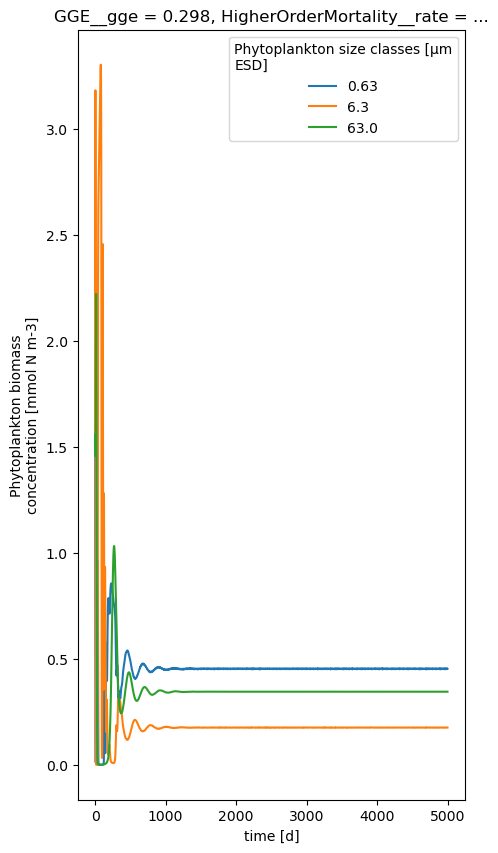

In [41]:
gge_mort_scan.isel(GGE__gge=24, HigherOrderMortality__rate=1).Phytoplankton__biomass.plot.line(x='time')

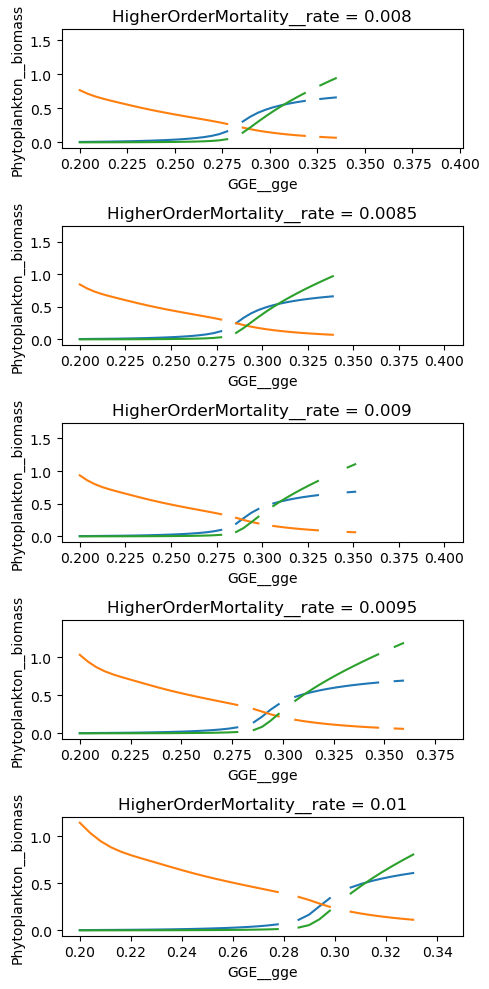

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

parsetind_toplot = [0,1,2,3,4]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (gge_mort_scan
        .isel(time=slice(365*9,365*10), HigherOrderMortality__rate=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='GGE__gge', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()

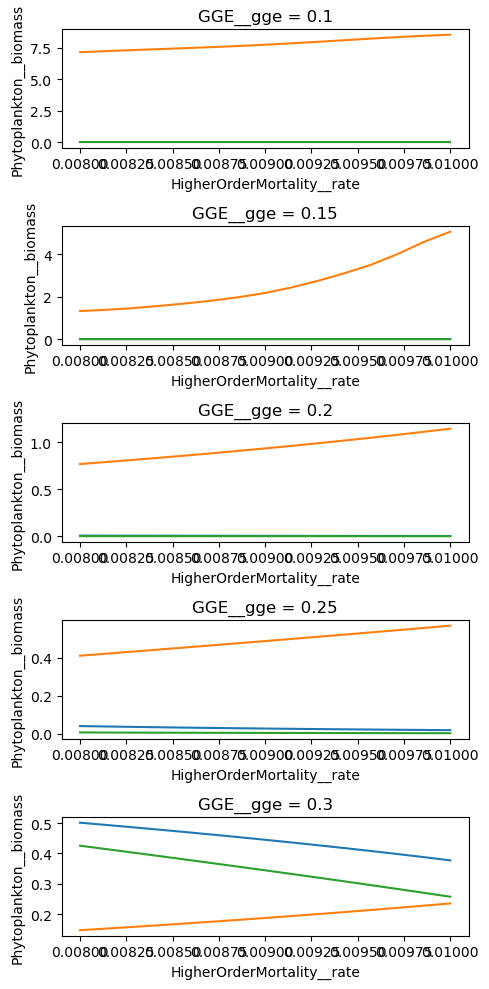

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

parsetind_toplot = [0,1,2,3,4]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (gge_mort_scan
        .isel(time=slice(365*9,365*10), GGE__gge=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='HigherOrderMortality__rate', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()

In [ ]:
# Now lets test Ks as a par

In [55]:
KsZ_mort_scan_input = generate_iterable_2d_parscan('HigherOrderMortality__rate', np.linspace(0.001,0.0035, 5),
                                                   'Grazing__KsZ', np.linspace(2.0,4.0, 50))

KsZ_mort_scan = run_model_get_output(KsZ_mort_scan_input)

pool started
running HigherOrderMortality__rate 0.001 Grazing__KsZ
running HigherOrderMortality__rate 0.0016250000000000001 Grazing__KsZ
running HigherOrderMortality__rate 0.0022500000000000003 Grazing__KsZ
running HigherOrderMortality__rate 0.002875 Grazing__KsZ
running HigherOrderMortality__rate 0.0035 Grazing__KsZ
Full scan done in  109.51447 seconds
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [587.71551501]
No event detected
No event detected
Event triggered at t = [444.88224934]
No event detected
No event detected
No event detected
No event detected
No event detected
No event d

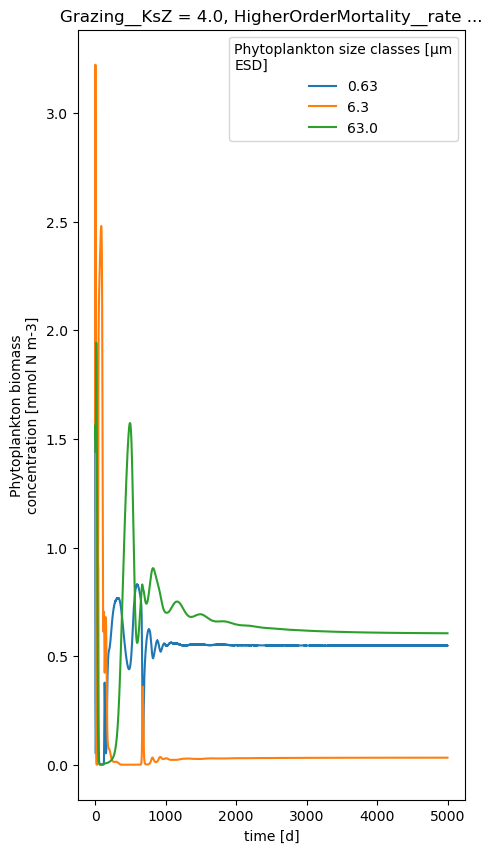

In [56]:
KsZ_mort_scan.isel(Grazing__KsZ=49, HigherOrderMortality__rate=1).Phytoplankton__biomass.plot.line(x='time')

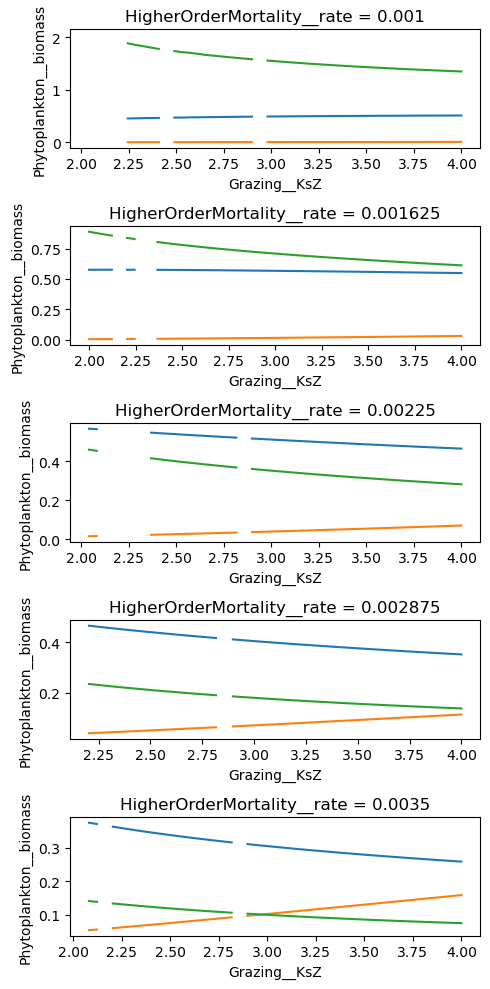

In [57]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 10]

parsetind_toplot = [0,1,2,3,4]

fig, ax = plt.subplots(len(parsetind_toplot))
                       
for ind, val in enumerate(parsetind_toplot):
    (KsZ_mort_scan
        .isel(time=slice(365*9,365*10), HigherOrderMortality__rate=val)
        .Phytoplankton__biomass.mean(dim="time").plot.line(x='Grazing__KsZ', ax=ax[ind], add_legend=False))#, ylim=(0,1)))

plt.tight_layout()

In [58]:
KsZ_mort_scan

<xarray.Dataset> Size: 630MB
Dimensions:                                         (Grazing__KsZ: 50,
                                                     HigherOrderMortality__rate: 5,
                                                     zoo: 4, time: 5000,
                                                     phyto: 3, full: 7, clock: 2)
Coordinates:
  * Grazing__KsZ                                    (Grazing__KsZ) float64 400B ...
  * HigherOrderMortality__rate                      (HigherOrderMortality__rate) float64 40B ...
  * clock                                           (clock) int64 16B 0 1
  * phyto                                           (phyto) float64 24B 0.63 ...
  * time                                            (time) float64 40kB 0.0 ....
  * zoo                                             (zoo) float64 32B 6.3 ......
Dimensions without coordinates: full
Data variables: (12/55)
    Core__solver_type                               (Grazing__KsZ, HigherOrderMortality__rate) <U9 9kB ...
    GGE__R                                          (Grazing__KsZ, HigherOrderMortality__rate) float64 2kB ...
    GGE__alpha                                      (Grazing__KsZ, HigherOrderMortality__rate) float64 2kB ...
    GGE__assimilated_consumer                       (Grazing__KsZ, HigherOrderMortality__rate) <U1 1kB ...
    GGE__assimilation_value                         (Grazing__KsZ, HigherOrderMortality__rate, zoo, time) float64 40MB ...
    GGE__egested_detritus                           (Grazing__KsZ, HigherOrderMortality__rate) <U1 1kB ...
    ...                                              ...
    Phytoplankton__phyto_index                      (Grazing__KsZ, HigherOrderMortality__rate, phyto) float64 6kB ...
    Time__time_input                                (Grazing__KsZ, HigherOrderMortality__rate, time) int64 10MB ...
    Zooplankton__biomass                            (Grazing__KsZ, HigherOrderMortality__rate, zoo, time) float64 40MB ...
    Zooplankton__biomass_init                       (Grazing__KsZ, HigherOrderMortality__rate, zoo) float64 8kB ...
    Zooplankton__biomass_label                      (Grazing__KsZ, HigherOrderMortality__rate) <U1 1kB ...
    Zooplankton__zoo_index                          (Grazing__KsZ, HigherOrderMortality__rate, zoo) float64 8kB ...

In [71]:
relative_composition[0,6]

<xarray.DataArray 'Phytoplankton__biomass' (phyto: 3)> Size: 24B
array([1.93655394e-01, 3.54002768e-04, 8.05990603e-01])
Coordinates:
    Grazing__KsZ                float64 8B 2.245
    HigherOrderMortality__rate  float64 8B 0.001
  * phyto                       (phyto) float64 24B 0.63 6.3 63.0

In [73]:
KsZ_mort_scan_input_X = generate_iterable_2d_parscan('HigherOrderMortality__rate', np.linspace(0.001,0.01, 50),
                                                   'GGE__gge', np.linspace(0.1,0.5, 50))

KsZ_mort_scan_X = run_model_get_output(KsZ_mort_scan_input_X)

pool started
running HigherOrderMortality__rate 0.001 GGE__gge


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running HigherOrderMortality__rate 0.0011836734693877551 GGE__gge


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running HigherOrderMortality__rate 0.0013673469387755102 GGE__gge


...

running HigherOrderMortality__rate 0.009816326530612245 GGE__gge


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


running HigherOrderMortality__rate 0.01 GGE__gge


/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5
/Users/aoop/Documents/GitHub/Research/SSMCariaco/FirstTestRuns/Stocketal2008_comps.py:183: RuntimeWarning: invalid value encountered in divide
  graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/self.m.sum((biomass * phiPZ)**2, axis=1))**0.5


Full scan done in  1376.96872 seconds
No event detected
No event detected
Event triggered at t = [110.89868839]
Event triggered at t = [134.6543558]
Event triggered at t = [82.12712093]
Event triggered at t = [96.62218129]
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [89.92589323]
No event detected
No event detected
No event detected
No event detected
Event triggered at t = [161.94691124]
No event detected
No event detected
Event triggered at t = [111.15084493]
Event triggered at t = [96.71200812]
No event detected
No event detected
Event triggered at t = [27.7289355]
Event triggered at t = [134.51708146]
Event triggered at t = [90.63422172]
No event detected
No event detected
Event triggered at t = [872.81151059]
Event triggered at t = [2194.40067841]
No event detected
No event detected
No event detected
Event triggered at t = [94.62785396]
Event triggered at t = [102.22121421]
Event triggered at t = [103.53067797]
No event detected
No

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.1133366676841e-41..0.6721994871194312].


ValueError: If given, 'extent' must be None or (x0, x1, y0, y1)

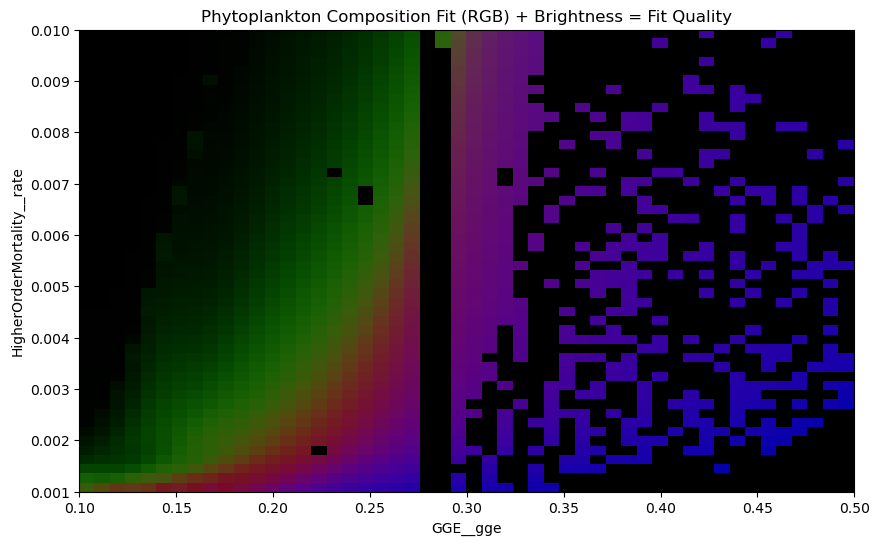

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# --- Parameters ---
target_composition = np.array([0.261,0.199, 0.539])  # Replace with your desired target
start_time = 365 * 9  # Start of last year
end_time = 365 * 10   # End of last year

# --- Slice and average over the last year ---
biomass = KsZ_mort_scan_X.Phytoplankton__biomass.isel(time=slice(start_time, end_time))
biomass_mean = biomass.mean(dim='time')  # dims: (Grazing__KsZ, HigherOrderMortality__rate, phyto)

# Transpose so the dimensions are (HigherOrderMortality__rate, Grazing__KsZ, phyto)
biomass_mean = biomass_mean.transpose('HigherOrderMortality__rate', 'GGE__gge', 'phyto')

# --- Normalize each (i,j) point to relative composition ---
total_biomass = biomass_mean.sum(dim='phyto')
relative_composition = biomass_mean / total_biomass  # still an xarray.DataArray

# Fill NaNs (e.g. if total biomass is 0) with zeros
relative_composition = relative_composition.fillna(0)

# --- Compute distance to target composition ---
# Convert to numpy array for vector operations
rel_np = relative_composition.values  # shape: (rate, ksZ, phyto)
dist = np.linalg.norm(rel_np - target_composition, axis=2)  # shape: (rate, ksZ)

# Normalize distance to [0, 1] and convert to brightness
dist_norm = dist / dist.max()
brightness = 1 - dist_norm  # higher brightness = better fit

# Expand brightness to RGB channels
brightness_exp = np.expand_dims(brightness, axis=2)  # shape: (rate, ksZ, 1)

gamma = 0.5  # <1 boosts brightness contrast; >1 compresses it
brightness_gamma = brightness ** gamma
rgb = rel_np * brightness_gamma[..., np.newaxis]


# --- Create RGB image ---
#rgb = rel_np * brightness_exp  # scales each pixel's RGB by its brightness

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.imshow(rgb, origin='lower', aspect='auto',
           extent=[
               float(biomass_mean.GGE__gge.min()),
               float(biomass_mean.GGE__gge.max()),
               float(biomass_mean.HigherOrderMortality__rate.min()),
               float(biomass_mean.HigherOrderMortality__rate.max())
           ])
plt.xlabel('GGE__gge')
plt.ylabel('HigherOrderMortality__rate')
plt.title('Phytoplankton Composition Fit (RGB) + Brightness = Fit Quality')
plt.grid(False)

#plt.imshow(rgb, origin='lower', aspect='auto', extent=[...])
cs = plt.contour(dist, levels=[0.01], colors='white', linewidths=1, extent=[...])
plt.clabel(cs, fmt='Perfect match', inline=True)


plt.show()

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='red', label='Phyto 1 dominates'),
    Patch(facecolor='green', label='Phyto 2 dominates'),
    Patch(facecolor='blue', label='Phyto 3 dominates'),
    Patch(facecolor='white', label='Perfect match to target'),
    Patch(facecolor='black', label='Poor match')
]
plt.legend(handles=legend_elements, loc='lower right')


0.18649138141328228


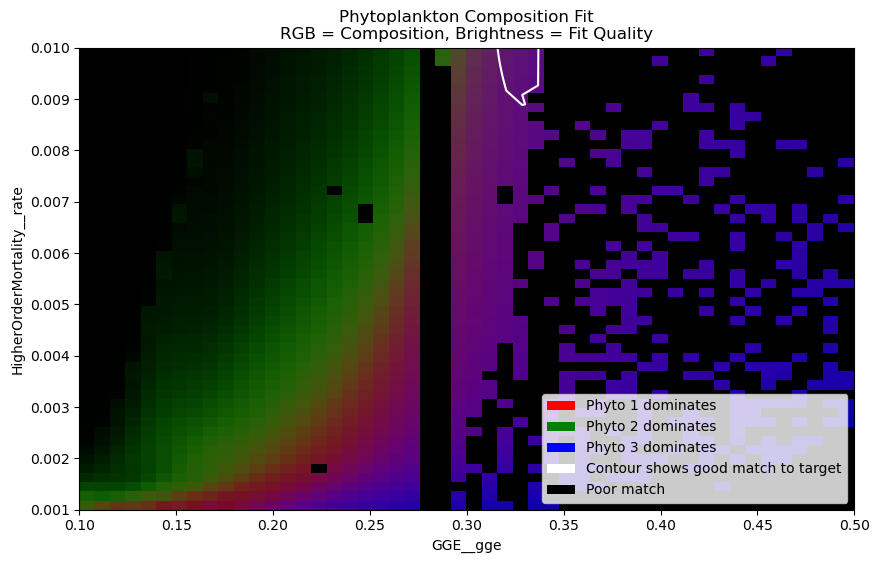

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# --- Parameters ---
target_composition = np.array([0.261, 0.199, 0.539])  # Replace with your desired target
start_time = 365 * 9
end_time = 365 * 10

# --- Slice and average over the last year ---
biomass = KsZ_mort_scan_X.Phytoplankton__biomass.isel(time=slice(start_time, end_time))
biomass_mean = biomass.mean(dim='time')

# Transpose so dimensions are (HigherOrderMortality__rate, GGE__gge, phyto)
biomass_mean = biomass_mean.transpose('HigherOrderMortality__rate', 'GGE__gge', 'phyto')

# --- Normalize each (i,j) point to relative composition ---
total_biomass = biomass_mean.sum(dim='phyto')
relative_composition = biomass_mean / total_biomass
relative_composition = relative_composition.fillna(0)

# --- Compute distance to target composition ---
rel_np = relative_composition.values  # shape: (rate, gge, phyto)
dist = np.linalg.norm(rel_np - target_composition, axis=2)  # shape: (rate, gge)
print(dist.min())
# Normalize and compute brightness
dist_max = np.percentile(dist, 95)
dist_clipped = np.clip(dist, 0, dist_max)
dist_norm = dist_clipped / dist_max
brightness = 1 - dist_norm

# Apply gamma correction
gamma = 0.5
brightness_gamma = brightness ** gamma
rgb = rel_np * brightness_gamma[..., np.newaxis]

# Clean up RGB array for imshow
rgb = np.nan_to_num(rgb, nan=0.0)
rgb = np.clip(rgb, 0, 1)

# --- Prepare coordinate grids for contour ---
x_vals = biomass_mean.GGE__gge.values  # Horizontal axis
y_vals = biomass_mean.HigherOrderMortality__rate.values  # Vertical axis
X, Y = np.meshgrid(x_vals, y_vals)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.imshow(rgb, origin='lower', aspect='auto',
           extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()])
plt.xlabel('GGE__gge')
plt.ylabel('HigherOrderMortality__rate')
plt.title('Phytoplankton Composition Fit\nRGB = Composition, Brightness = Fit Quality')
plt.grid(False)

# Overlay contour for perfect match
cs = plt.contour(X, Y, dist,levels = [0.02, 0.05, 0.1, 0.15, 0.2] , colors='white', linewidths=1.5)
plt.clabel(cs, fmt='Perfect match', inline=True)


legend_elements = [
    Patch(facecolor='red', label='Phyto 1 dominates'),
    Patch(facecolor='green', label='Phyto 2 dominates'),
    Patch(facecolor='blue', label='Phyto 3 dominates'),
    Patch(facecolor='white', label='Contour shows good match to target'),
    Patch(facecolor='black', label='Poor match')
]
plt.legend(handles=legend_elements, loc='lower right')


plt.show()


In [86]:
# Find the index of the minimum distance
flat_index = np.argmin(dist)
best_i, best_j = np.unravel_index(flat_index, dist.shape)

# If you transposed `dist` earlier, adjust the indices
if dist.shape != (len(y_vals), len(x_vals)):
    best_j, best_i = best_i, best_j

# Retrieve the corresponding parameter values
best_gge = x_vals[best_j]
best_mortality = y_vals[best_i]
best_dist = dist[best_i, best_j]

# Print result
print(f"Best fit found at:")
print(f"  GGE__gge = {best_gge}")
print(f"  HigherOrderMortality__rate = {best_mortality}")
print(f"  Distance to target = {best_dist}")


Best fit found at:
  GGE__gge = 0.3285714285714286
  HigherOrderMortality__rate = 0.01
  Distance to target = 0.18649138141328228
